# MSME data audit and distributions
Reuses the supplied notebook's quality, range, distribution, and correlation analysis. Fixes correlation export, excludes ID listings, and adds grouped/log-scale analysis. Original notebook retained locally in `local/`.

**Input:** supplied 50,000-business synthetic CSV. Source rows are not displayed or exported. IQR flags are diagnostics, not deletion rules. No dated transactions or observed defaults exist.

In [1]:
from pathlib import Path
import hashlib, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scoring import RAW, TARGETS, SCORES, Business
assert Path(sys.prefix).name == 'ml', 'Activate conda ml and select its kernel.'
ROOT=Path.cwd(); output=ROOT/'data_quality_reports'; output.mkdir(exist_ok=True)
reports=ROOT/'reports'; reports.mkdir(exist_ok=True)
df=pd.read_csv(ROOT/'msme_synthetic_50k.csv')
numeric=df.select_dtypes('number')
print({'shape':df.shape,'duplicate_ids':int(df.MSME_ID.duplicated().sum()),
       'duplicates_without_id':int(df.drop(columns='MSME_ID').duplicated().sum())})
assert set(df.columns)==set(['MSME_ID']+RAW+TARGETS)
print('SHA256:',hashlib.sha256((ROOT/'msme_synthetic_50k.csv').read_bytes()).hexdigest())

Matplotlib is building the font cache; this may take a moment.


{'shape': (50000, 45), 'duplicate_ids': 0, 'duplicates_without_id': 0}
SHA256: 6a456ac34188b5e13acfd302926796bf5b9132afa889a96b3eecb7d45a37aeb9


In [2]:
quality=pd.DataFrame({'dtype':df.dtypes.astype(str),'unique_values':df.nunique(),
                      'missing_values':df.isna().sum(),'missing_pct':100*df.isna().mean()})
missing=quality.loc[quality.missing_values.gt(0),['missing_values','missing_pct']]
display(missing)
display(pd.crosstab(df.Has_Existing_Loan,df.EMI_On_Time_Rate_Pct.isna()))
assert df.EMI_On_Time_Rate_Pct.isna().equals(df.Has_Existing_Loan.eq('No'))
assert df.Credit_History_Months.eq(0).equals(df.Has_Existing_Loan.eq('No'))
print('Missing EMI history is structural. Zero history is a dataset pattern, not a universal business rule.')
quality.to_csv(output/'quality_report.csv')
missing.rename(columns={'missing_values':'Missing_Count','missing_pct':'Missing_Pct'}).to_csv(output/'missing_report.csv')

,missing_values,missing_pct
EMI_On_Time_Rate_Pct,32556,65.112


EMI_On_Time_Rate_Pct,False,True
Has_Existing_Loan,,
No,0,32556
Yes,17444,0


Missing EMI history is structural. Zero history is a dataset pattern, not a universal business rule.


In [3]:
# The same Pydantic contract validates CSV input and REST snapshots.
raw=df[['MSME_ID']+RAW].astype(object).where(df[['MSME_ID']+RAW].notna(),None)
for row in raw.to_dict('records'): Business.model_validate(row)
ranges={c:(0,100) for c in SCORES+['GST_Filing_Timeliness_Pct','EMI_On_Time_Rate_Pct','Salary_Consistency_Pct','Vendor_Payment_Timeliness_Pct','Employee_Attrition_Rate_Pct']}
ranges.update({c:(0,1) for c in ['Probability_of_Default','Customer_Concentration_Ratio','Overdraft_Usage_Ratio','Cashflow_Stability_Index','Seasonality_Index','Transaction_Volatility_Index']})
ranges.update({c:(0,np.inf) for c in df if c.endswith('_INR')})
invalid=pd.DataFrame([{'column':c,'expected_range':f'{lo} to {hi}',
 'invalid_count':int((df[c].notna() & ~df[c].between(lo,hi)).sum())} for c,(lo,hi) in ranges.items()])
invalid['invalid_pct']=100*invalid.invalid_count/len(df)
assert invalid.invalid_count.sum()==0
assert np.isfinite(numeric.to_numpy()[numeric.notna().to_numpy()]).all()
invalid.to_csv(output/'invalid_values_report.csv',index=False)
print(f'{len(raw):,} snapshots pass input contract; {len(invalid)} range checks pass.')
print('Businesses with bank deficit:',int(df.Monthly_Bank_Debits_INR.gt(df.Monthly_Bank_Credits_INR).sum()))

50,000 snapshots pass input contract; 30 range checks pass.
Businesses with bank deficit: 865


In [4]:
distribution=numeric.describe().T
distribution['missing_pct']=100*numeric.isna().mean()
distribution['skewness']=numeric.skew()
distribution['zero_pct']=100*numeric.eq(0).mean()
for c in numeric:
    v=numeric[c].dropna(); q1,q3=v.quantile([.25,.75]); iqr=q3-q1
    distribution.loc[c,'outlier_pct']=100*((v<q1-1.5*iqr)|(v>q3+1.5*iqr)).mean()
distribution.to_csv(output/'distribution_report.csv')
display(distribution[['50%','skewness','zero_pct','outlier_pct']].sort_values('skewness',ascending=False).head(14))
numeric.quantile([.01,.5,.9,.95,.99,.999]).T.to_csv(output/'tail_quantiles.csv')
money=[c for c in RAW if c.endswith('_INR')]
skew=pd.DataFrame({'raw':df[money].skew(),'log1p':np.log1p(df[money]).skew()})
display(skew.round(3))
print('Positive loan EMI and credit limits inspected separately from structural zeros.')
print({'borrower_log_emi_skew':np.log1p(df.loc[df.Has_Existing_Loan.eq('Yes'),'Monthly_Loan_EMI_INR']).skew(),
 'eligible_log_limit_skew':np.log1p(df.loc[df.Credit_Eligible.eq('Yes'),'Recommended_Credit_Limit_INR']).skew()})

,50%,skewness,zero_pct,outlier_pct
Monthly_Loan_EMI_INR,0.0,9.588233,65.112,15.102
UPI_Avg_Ticket_Size_INR,491.0,8.176173,0.000,10.352
Monthly_UPI_Inflow_INR,129439.5,7.755996,0.000,8.668
Monthly_UPI_Outflow_INR,72570.5,7.449426,0.000,8.786
Recommended_Credit_Limit_INR,340000.0,6.935905,25.670,7.854
Average_Bank_Balance_INR,195073.0,6.769388,0.000,8.700
Monthly_Bank_Debits_INR,326745.0,5.919155,0.000,8.126
Monthly_GST_Purchases_INR,249107.5,5.816281,0.000,8.268
Monthly_Bank_Credits_INR,413055.0,5.725390,0.000,8.242
Monthly_GST_Sales_INR,401682.0,5.632090,0.000,8.164


,raw,log1p
Annual_Turnover_INR,5.594,0.030
Monthly_GST_Sales_INR,5.632,0.030
Monthly_GST_Purchases_INR,5.816,0.025
Monthly_UPI_Inflow_INR,7.756,-0.080
Monthly_UPI_Outflow_INR,7.449,-0.092
UPI_Avg_Ticket_Size_INR,8.176,0.769
Monthly_Bank_Credits_INR,5.725,0.031
Monthly_Bank_Debits_INR,5.919,0.033
Average_Bank_Balance_INR,6.769,-0.188
Monthly_Loan_EMI_INR,9.588,0.692


Positive loan EMI and credit limits inspected separately from structural zeros.
{'borrower_log_emi_skew': np.float64(-0.13679072661972652), 'eligible_log_limit_skew': np.float64(0.042594702623938135)}


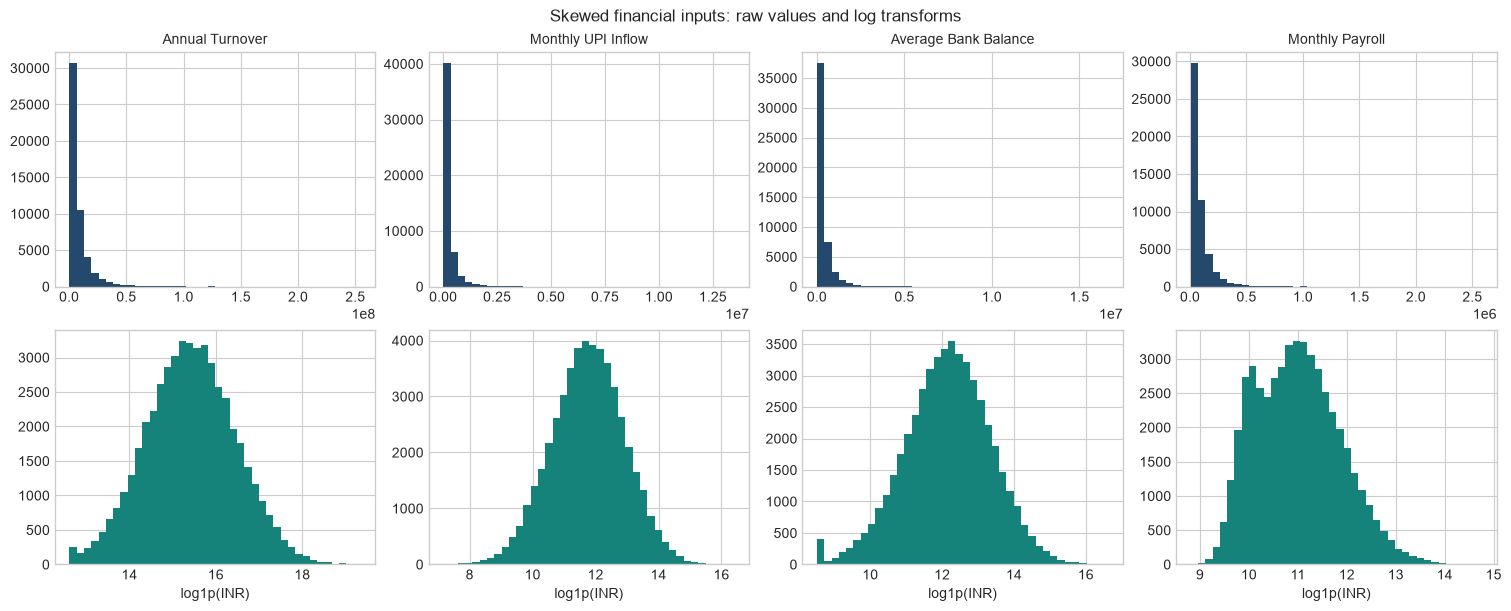

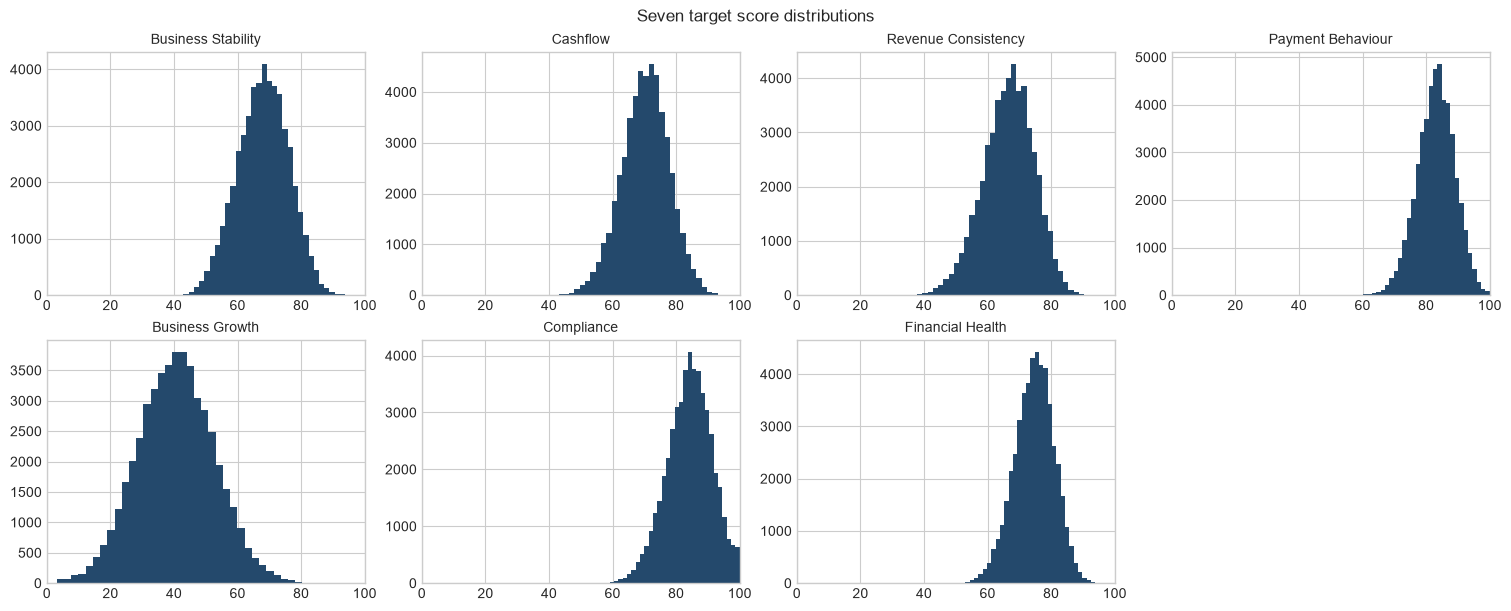

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
columns=['Annual_Turnover_INR','Monthly_UPI_Inflow_INR','Average_Bank_Balance_INR','Monthly_Payroll_INR']
fig,axes=plt.subplots(2,4,figsize=(15,6),layout='constrained')
for j,c in enumerate(columns):
    axes[0,j].hist(df[c],bins=40,color='#24496c'); axes[0,j].set_title(c.replace('_INR','').replace('_',' '),fontsize=10)
    axes[1,j].hist(np.log1p(df[c]),bins=40,color='#16837a'); axes[1,j].set_xlabel('log1p(INR)')
fig.suptitle('Skewed financial inputs: raw values and log transforms')
fig.savefig(reports/'distributions.png',dpi=150); plt.show()
fig,axes=plt.subplots(2,4,figsize=(15,6),layout='constrained')
for ax,c in zip(axes.flat,SCORES):
    ax.hist(df[c],bins=35,color='#24496c'); ax.set_title(c.replace('_Score','').replace('_',' '),fontsize=10); ax.set_xlim(0,100)
axes.flat[-1].axis('off');fig.suptitle('Seven target score distributions')
fig.savefig(reports/'score_distributions.png',dpi=150);plt.show()

,feature_1,feature_2,correlation
119,Monthly_GST_Sales_INR,Monthly_Bank_Credits_INR,0.996302
75,Annual_Turnover_INR,Monthly_GST_Sales_INR,0.995203
83,Annual_Turnover_INR,Monthly_Bank_Credits_INR,0.991318
408,Monthly_Bank_Credits_INR,Monthly_Bank_Debits_INR,0.988776
212,GST_Filing_Timeliness_Pct,Compliance_Score,0.987848
120,Monthly_GST_Sales_INR,Monthly_Bank_Debits_INR,0.985026
84,Annual_Turnover_INR,Monthly_Bank_Debits_INR,0.980041
931,Revenue_Growth_Rate_Pct,Business_Growth_Score,0.974444
112,Monthly_GST_Sales_INR,Monthly_GST_Purchases_INR,0.968340
155,Monthly_GST_Purchases_INR,Monthly_Bank_Credits_INR,0.964484


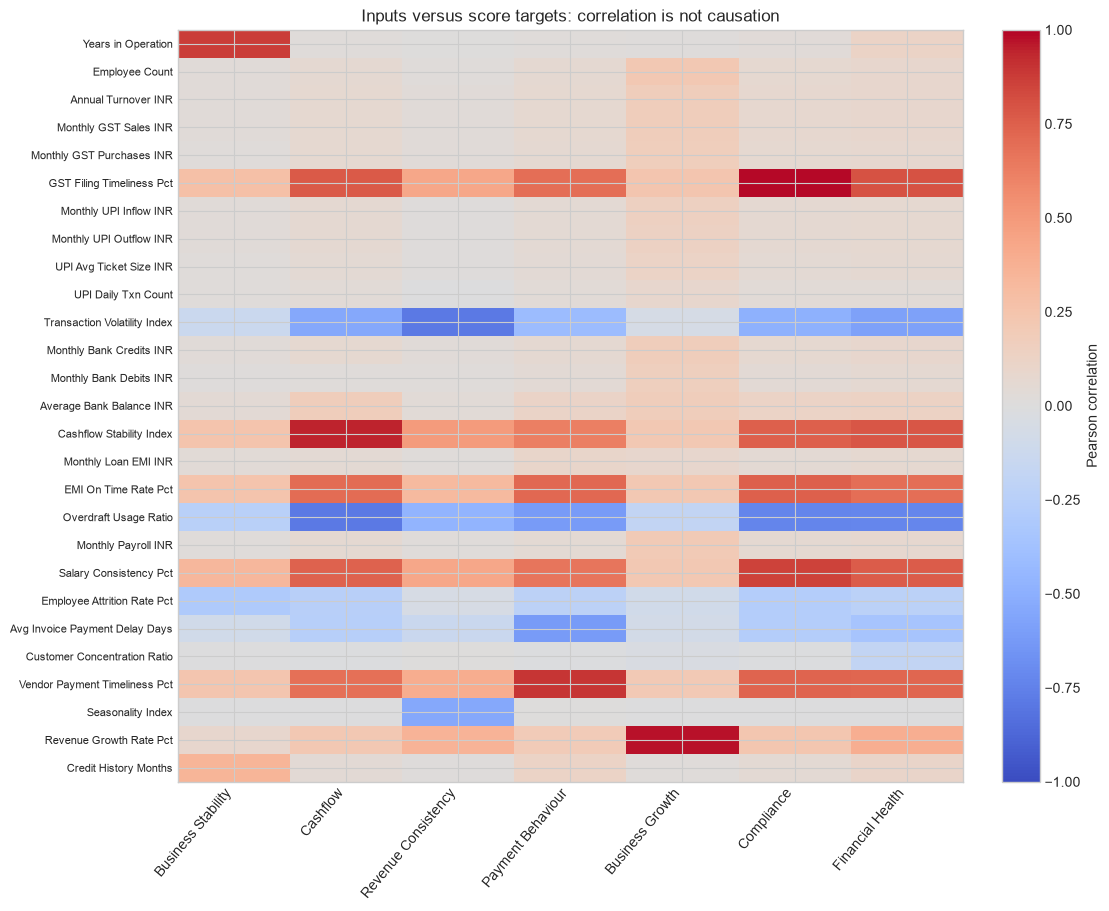

,Monthly_GST_Sales_INR,Compliance_Score,Recommended_Credit_Limit_INR
Annual_Turnover_INR,0.997,0.092,0.584
GST_Filing_Timeliness_Pct,0.090,0.987,0.576


In [6]:
correlation=numeric.corr()
pairs=correlation.where(np.triu(np.ones(correlation.shape),k=1).astype(bool)).stack().rename('correlation').reset_index()
pairs.columns=['feature_1','feature_2','correlation']
high=pairs.loc[pairs.correlation.abs().ge(.90)].sort_values('correlation',key=lambda s:s.abs(),ascending=False)
assert len(high)==16 and not high[['feature_1','feature_2']].duplicated().any()
correlation.to_csv(output/'correlation_matrix.csv')
high.to_csv(output/'high_correlations.csv',index=False)
inputs=[c for c in RAW if c in numeric]
correlation.loc[inputs,inputs].to_csv(output/'input_correlations.csv')
correlation.loc[inputs,[c for c in TARGETS if c in numeric]].to_csv(output/'input_target_correlations.csv')
display(high)
fig,ax=plt.subplots(figsize=(11,9),layout='constrained')
im=ax.imshow(correlation.loc[inputs,SCORES],vmin=-1,vmax=1,cmap='coolwarm',aspect='auto')
ax.set_xticks(range(len(SCORES)),[c.replace('_Score','').replace('_',' ') for c in SCORES],rotation=50,ha='right')
ax.set_yticks(range(len(inputs)),[c.replace('_',' ') for c in inputs],fontsize=8)
fig.colorbar(im,ax=ax,label='Pearson correlation');ax.set_title('Inputs versus score targets: correlation is not causation')
fig.savefig(reports/'input_target_correlations.png',dpi=150);plt.show()
display(numeric.corr(method='spearman').loc[['Annual_Turnover_INR','GST_Filing_Timeliness_Pct'],['Monthly_GST_Sales_INR','Compliance_Score','Recommended_Credit_Limit_INR']].round(3))

,count,median_turnover,mean_health,eligible_pct
Customer_Segment,,,,
Existing-to-Credit,13965,5013410.0,75.40,77.62
NTB,14967,4932446.0,74.52,73.69
NTC,21068,4858123.0,74.29,72.61


,count,median_turnover,mean_health,eligible_pct
Industry,,,,
Construction,3078,6486111.5,74.83,74.50
Food & Beverage,5041,3568148.0,74.57,73.76
Healthcare,2485,4622847.0,74.70,74.69
IT & Digital,2504,3874413.5,74.57,73.80
Logistics,3559,5582652.0,74.73,74.74
Manufacturing,6456,7019007.0,74.70,74.36
Retail,9006,4372123.5,74.73,74.04
Services,8842,4088315.0,74.59,74.29
Textiles,2961,4692416.0,74.55,73.56


,count,median_turnover,mean_health,eligible_pct
Credit_Risk_Category,,,,
High,12832,4340873.5,66.71,0.00
Low,14882,5585489.5,81.63,100.00
Medium,22286,4930741.0,74.60,99.99


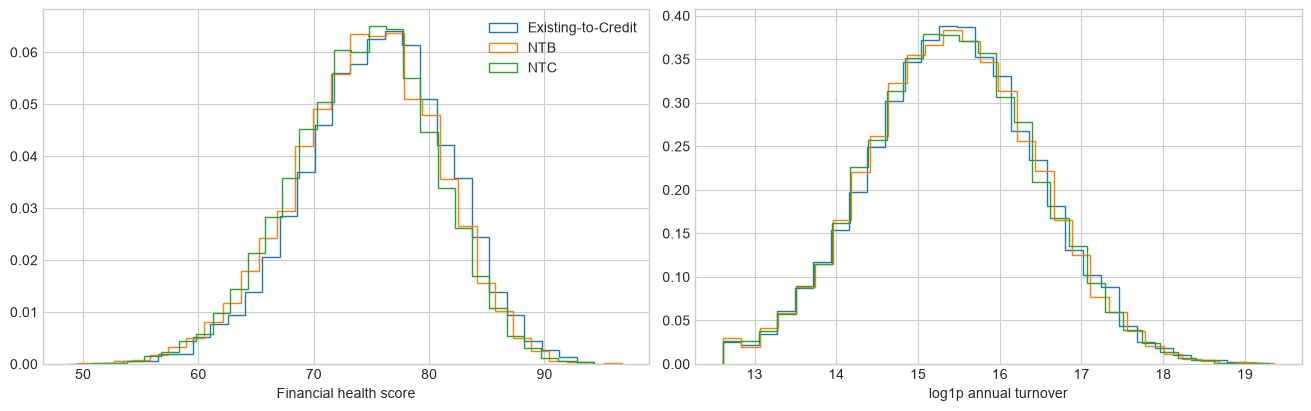

Credit_Eligible,No,Yes
Credit_Risk_Category,,
High,12832,0
Low,0,14882
Medium,3,22283


In [7]:
for group in ['Customer_Segment','Industry','Credit_Risk_Category']:
    summary=df.groupby(group).agg(count=('MSME_ID','size'),median_turnover=('Annual_Turnover_INR','median'),
       mean_health=('Financial_Health_Score','mean'),eligible_pct=('Credit_Eligible',lambda s:100*s.eq('Yes').mean()))
    display(summary.round(2));summary.to_csv(output/f'by_{group}.csv')
fig,axes=plt.subplots(1,2,figsize=(13,4),layout='constrained')
for segment,group in df.groupby('Customer_Segment'):
    axes[0].hist(group.Financial_Health_Score,bins=30,density=True,histtype='step',label=segment)
    axes[1].hist(np.log1p(group.Annual_Turnover_INR),bins=30,density=True,histtype='step',label=segment)
axes[0].set_xlabel('Financial health score');axes[1].set_xlabel('log1p annual turnover');axes[0].legend()
fig.savefig(reports/'segment_distributions.png',dpi=150);plt.show()
display(pd.crosstab(df.Credit_Risk_Category,df.Credit_Eligible))

## Modeling decisions
- Keep valid extremes; no winsorization or IQR deletion. Treat negative surplus as a risk signal.
- Log/scale nonnegative monetary and count inputs for linear models; retain raw values for CatBoost.
- Missing EMI rate is not failed repayment. Do not require credit history for NTC scoring.
- Evaluate full and compact feature sets. Correlated monetary values can split SHAP attribution.
- Strong score/input relationships justify Ridge baselines. All supplied outcomes remain targets only.
- No anomaly truth labels: review rates and controlled perturbations are diagnostics, not accuracy.
- Fixed held-out evaluation describes this synthetic generator only. No real default, fairness, historical-trend, or live-integration claims.